In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import xlrd
import os
import openpyxl
import numpy as np



In [2]:
def read_excel(file_path):
    # 打开文件
    path = file_path
    workBook = xlrd.open_workbook(path);
    ## 2.1 法1：按索引号获取sheet内容
    sheet1_content1 = workBook.sheet_by_index(0); # sheet索引从0开始

    colsx = sheet1_content1.col_values(0)# 获取第1列内容
    colsy = sheet1_content1.col_values(1)
    colsz = sheet1_content1.col_values(2)

    i1 = sheet1_content1.col_values(3)
    i2 = sheet1_content1.col_values(4)
    i3 = sheet1_content1.col_values(5)
    
    len1 = len(colsx) #打印一下列的长度
    len4 = len(colsy)
    inp=[]
    out=[]
    for i in range(1,len(colsx)):
        inp.append([i1[i],i2[i],i3[i]])
        out.append([colsx[i],colsy[i],colsz[i]])
        
    print(colsx[0])
    print(len4)
    return np.array(inp),np.array(out)

In [3]:
path="三维力.xlsx"
xFull,yFull =read_excel(path)

Fx
101


In [4]:
print(xFull[:3])
print(yFull[:3])

[[4115.8 2978.8 1973.3]
 [4227.1 2562.5 1987.3]
 [3791.5 2148.4 2148.4]]
[[ 0.004       0.004      -0.005     ]
 [ 0.00292207  0.00459492 -0.0032787 ]
 [-0.00464288  0.00349129 -0.00466997]]


In [5]:
# k-nearest neighbors for multioutput regression
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn import preprocessing

# create datasets
xKN, yKN = xFull[:80], yFull[:80]
scaler = preprocessing.StandardScaler().fit(xKN)
xKN = scaler.transform(xKN)

# define model
modelKN = KNeighborsRegressor(n_neighbors=9)
# fit model
modelKN.fit(xKN, yKN)
# make a prediction

data_in = scaler.transform(xFull[80:])
yhat = modelKN.predict(data_in)
# summarize prediction
for t,u in zip(yhat,yFull[80:]):
    print(t,u)


[ 0.00095519  0.00197617 -0.00140994] [ 0.0012406   0.00179136 -0.00197758]
[-0.00062364  0.00412129 -0.00278244] [-0.00132563  0.00487982 -0.00018869]
[ 0.00240677  0.00368063 -0.00318598] [ 0.00385168  0.00413287 -0.00398092]
[-0.00397777 -0.00244235 -0.00244006] [-0.00401288 -0.00238129 -0.00167678]
[ 0.00279996 -0.00205675 -0.00276444] [ 0.00179728 -0.00363447 -0.00360614]
[-0.00258363  0.00048796 -0.00263023] [-0.00393238  0.00153757 -0.00247087]
[ 0.00266436  0.00255658 -0.00287235] [ 0.00279052  0.00215037 -0.0045186 ]
[ 0.00317995 -0.00180557 -0.00305467] [ 0.00390923 -0.00165837 -0.00349373]
[-0.00363965 -0.00324857 -0.00306642] [-0.0030219  -0.00469459 -0.00372037]
[ 0.00050222  0.00045915 -0.00173241] [ 2.24355902e-07 -2.00778589e-04 -4.52361119e-03]
[ 0.00124729  0.00158961 -0.00159675] [ 0.00109867  0.00117666 -0.00429721]
[ 0.00167856 -0.00010483 -0.00255541] [ 0.00305489  0.00076722 -0.00091461]
[-0.00243214  0.00368643 -0.0018835 ] [-0.00260068  0.00386512 -0.00014337]


In [6]:
# random forest for multioutput regression, 随机森林
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
# define model
model = RandomForestRegressor()
model.fit(xKN,yKN)
yhat = model.predict(data_in)
# summarize prediction
print(yhat[0])

[ 0.00150372  0.00194283 -0.00190809]


[[41.158 29.788 19.733]
 [42.271 25.625 19.873]
 [37.915 21.484 21.484]
 [35.855 26.321 21.302]
 [28.823 23.905 23.924]]


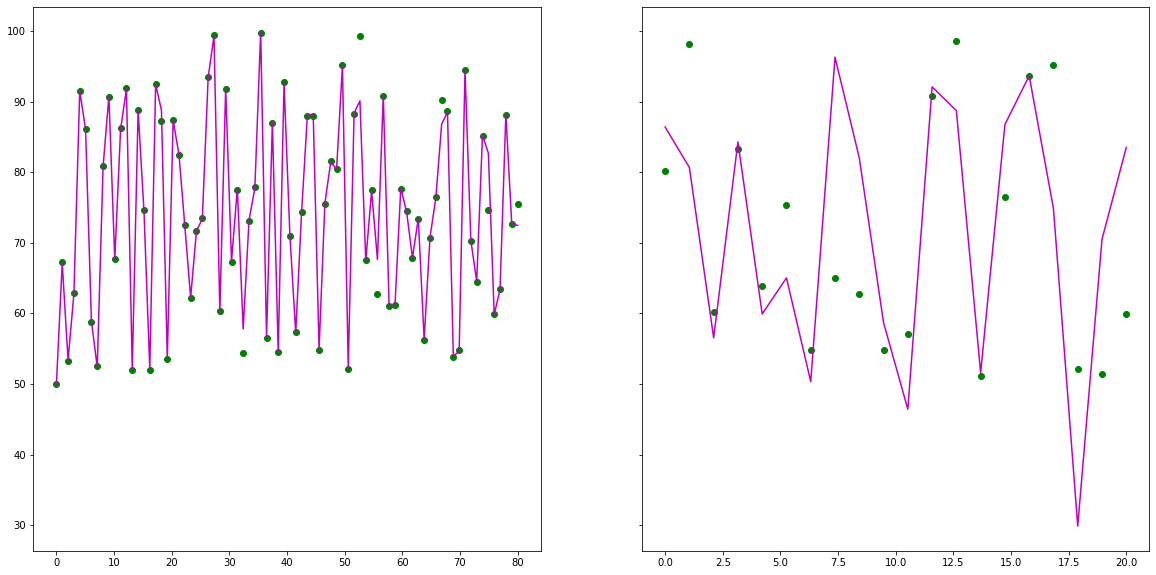

In [7]:
from sklearn.svm import SVR
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

index = 2 #Z方向的力

xTrain,yTrainZ = xFull[:80], yFull[:80, index]
xTrain = xTrain / 100.0
yTrainZ = yTrainZ * 10000 + 100

xTest, yTestZ =  xFull[80:], yFull[80:, index]
xTest = xTest / 100.0
yTestZ = yTestZ * 10000 + 100

scaler = preprocessing.StandardScaler()
scaler = scaler.fit(xTrain)
# XTrain = scaler.transform(xTrain)
print(xTrain[:5])

svr = SVR(kernel="rbf", C=1E4, gamma=0.02)
# svr_poly = SVR(kernel="poly", C=1E5, gamma=0.1, degree=9, epsilon=0.1, coef0=1)
# svr = svr_poly
svr.fit(xTrain,yTrainZ) #拟合数据

ypreTrain = svr.predict(xTrain) #预测训练集
# for t,g in zip(ypreTrain[:20] ,yTrainZ[:20]):
#     print(t,g)

# xTest = scaler.transform(xTest)
ypreTest = svr.predict(xTest) #对验证集预测
# for t,g in zip(ypreTest,yTestZ):
#     print(t,g)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10), sharey=True)  

xtrain = np.linspace(0,80, 80)
axes[0].plot(xtrain, ypreTrain, color='m')
axes[0].scatter(xtrain, yTrainZ, facecolor="g")
 
xtest = np.linspace(0,20, 20)
axes[1].plot(xtest, ypreTest, color='m')
axes[1].scatter(xtest, yTestZ, facecolor="g")

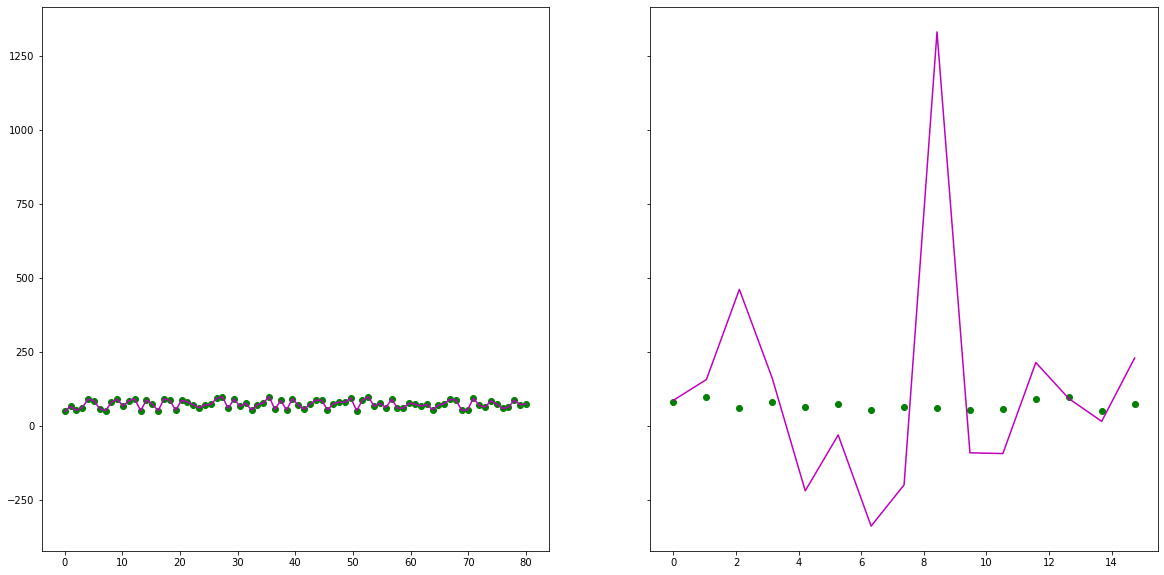

In [9]:
#多项式回归
from sklearn.preprocessing import  PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly_reg =PolynomialFeatures(degree=6)
XTrainPloy =poly_reg.fit_transform(xTrain)
XTestPloy =poly_reg.fit_transform(xTest)

lin_reg = LinearRegression()
lin_reg.fit(XTrainPloy, yTrainZ)

ypreTrain = lin_reg.predict(XTrainPloy) #预测训练集

ypreTest = lin_reg.predict(XTestPloy) #对验证集预测

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10), sharey=True)  

xtrain = np.linspace(0,80, 80)
axes[0].plot(xtrain, ypreTrain, color='m')
axes[0].scatter(xtrain, yTrainZ, facecolor="g")
 
xtest = np.linspace(0,20, 20)
axes[1].plot(xtest[:15], ypreTest[:15], color='m')
axes[1].scatter(xtest[:15], yTestZ[:15], facecolor="g")

In [ ]:
from sklearn.svm import SVR
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.fixes import loguniform
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold

index = 2

xTrain,yTrainZ=xFull[:80],yFull[:80,index]
scaler = preprocessing.StandardScaler().fit(xTrain)
xTrain = scaler.transform(xTrain)

# param_grid = {'C': loguniform(1e3, 1e8),
#  'gamma': loguniform(1e-4, 7e-1),
#  'kernel': ['rbf'],
#  'class_weight':['balanced', None]}

C_range = np.logspace(1e3, 1e7, 20)
gamma_range = np.logspace(-9, 13, 20)
param_grid = dict(gamma=gamma_range, C=C_range, kernel=['rbf'])
cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=0)
grid = GridSearchCV(SVR(), param_grid=param_grid, cv=cv)
grid.fit(xTrain, yTrainZ)

print(grid.best_params_)

# ypreTrain = pipe.predict(xTrain)
# # for t,g in zip(ypre,yFull[:80, 2]):
# #     print(t,g)
    
# ypre = pipe.predict(xFull[80:]) #对验证集做归一化再预测
# for t,g in zip(ypre,yFull[80:, index]):
#     print(t,g)
    
# xt = np.linspace(0,20, 20)
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10), sharey=True)
# axes[0].plot(xt, ypre, color='m')
# axes[0].scatter(xt, yFull[80:, index], facecolor="g")

# xtrain = np.linspace(0,80, 80)
# axes[1].plot(xtrain, ypreTrain, color='m')
# axes[1].scatter(xtrain, yFull[:80, index], facecolor="g")
